In [2]:
#TASK 1 - IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [3]:
#TASK 2 - LOAD DATASET
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully



Dataset Dimensions
(7043, 21)

First 5 Records
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport 

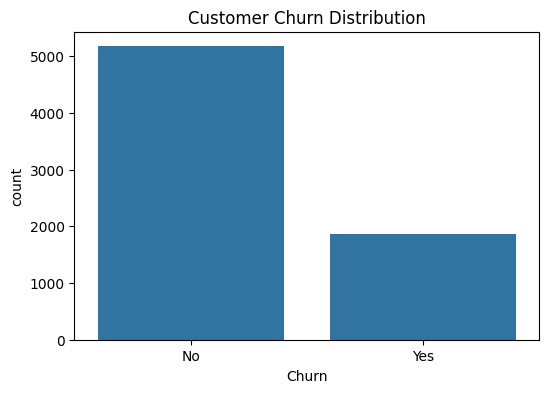

In [4]:
#TASK 3 - EDA
print("\nDataset Dimensions")
print(df.shape)

print("\nFirst 5 Records")
print(df.head())

print("\nMissing Values")
print(df.isnull().sum())

print("\nData Types")
print(df.dtypes)

print("\nStatistical Summary")
print(df.describe())

# Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [5]:
# TASK 4 - PREPROCESSING
# Remove Customer ID
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Handle Missing Values
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

# Remove Duplicate Records
df = df.drop_duplicates()

# Encode Categorical Variables
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

# Separate Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Standardization
scaler = StandardScaler()
X = scaler.fit_transform(X)
print("\nPreprocessing Completed")


Preprocessing Completed


In [6]:
# TASK 5 - TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (5616, 19)
Testing Shape: (1405, 19)


In [7]:
# TASK 6 - TRAIN MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}
results = []


Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.53      0.58       372

    accuracy                           0.80      1405
   macro avg       0.74      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



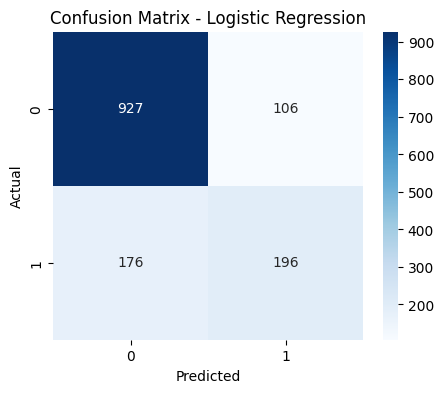


Decision Tree
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1033
           1       0.45      0.46      0.46       372

    accuracy                           0.71      1405
   macro avg       0.63      0.63      0.63      1405
weighted avg       0.71      0.71      0.71      1405



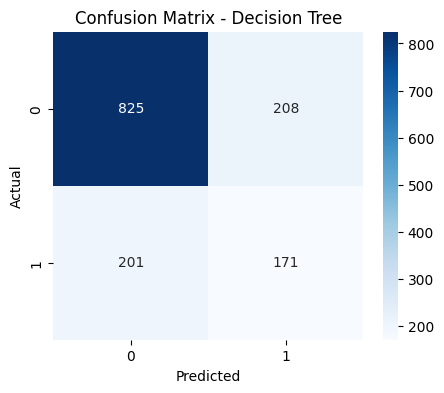


Random Forest
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.45      0.52       372

    accuracy                           0.78      1405
   macro avg       0.72      0.67      0.69      1405
weighted avg       0.77      0.78      0.77      1405



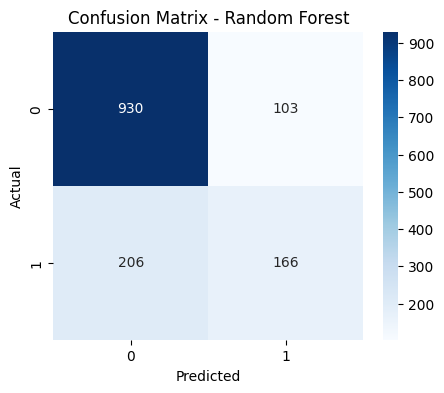


SVM
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1033
           1       0.66      0.45      0.54       372

    accuracy                           0.79      1405
   macro avg       0.74      0.68      0.70      1405
weighted avg       0.78      0.79      0.78      1405



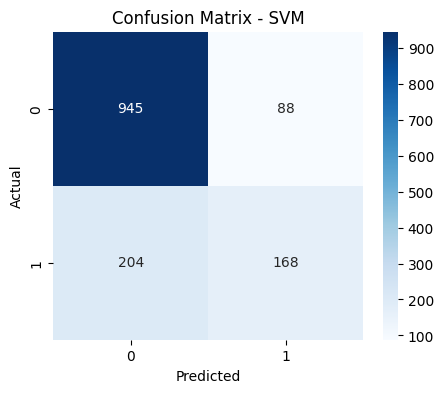


Gradient Boosting
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.51      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



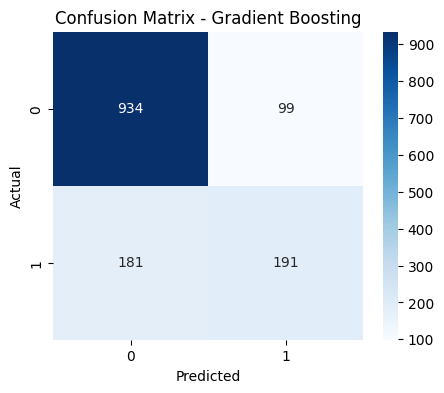

In [8]:
# TASK 7 - EVALUATE MODELS
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc])
    print("\n" + "="*50)
    print(name)
    print("="*50)
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [9]:
# TASK 8 - COMPARISON TABLE
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)
print("\nComparison Table")
print(comparison_df)


Comparison Table
             Algorithm  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.799288   0.649007  0.526882  0.581602  0.838753
1        Decision Tree  0.708897   0.451187  0.459677  0.455393  0.629973
2        Random Forest  0.780071   0.617100  0.446237  0.517941  0.813466
3                  SVM  0.792171   0.656250  0.451613  0.535032  0.786717
4    Gradient Boosting  0.800712   0.658621  0.513441  0.577039  0.837952


In [10]:
# TASK 9 - BEST MODEL
best_model = comparison_df.loc[
    comparison_df["ROC-AUC"].idxmax()
]
print("\nBest Performing Model")
print(best_model)


Best Performing Model
Algorithm    Logistic Regression
Accuracy                0.799288
Precision               0.649007
Recall                  0.526882
F1 Score                0.581602
ROC-AUC                 0.838753
Name: 0, dtype: object



Top 10 Important Features
            Feature  Importance
18     TotalCharges    0.188614
17   MonthlyCharges    0.180115
4            tenure    0.154797
14         Contract    0.075327
16    PaymentMethod    0.050497
8    OnlineSecurity    0.048049
11      TechSupport    0.044539
9      OnlineBackup    0.028313
7   InternetService    0.027778
0            gender    0.026789


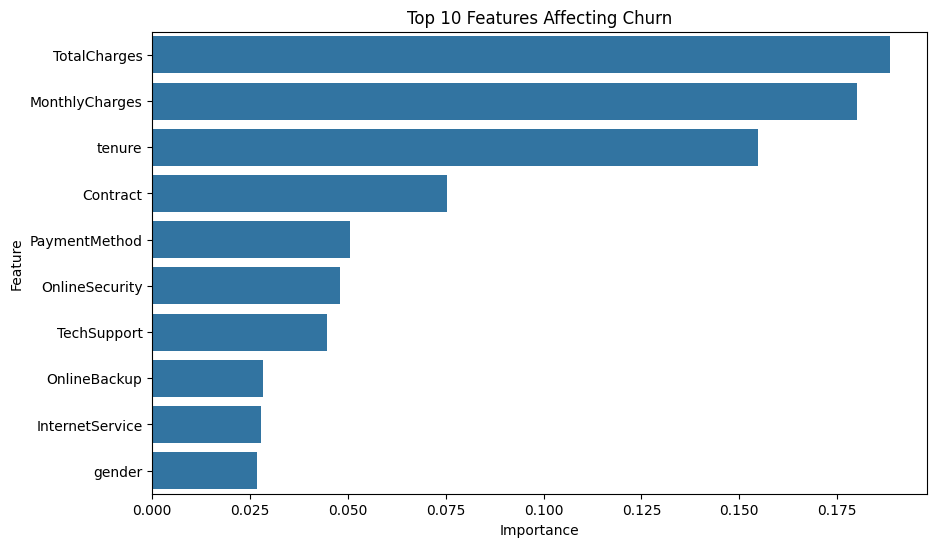

In [11]:
# TASK 10 - FEATURE IMPORTANCE
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
feature_names = df.drop("Churn", axis=1).columns
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
print("\nTop 10 Important Features")
print(importance_df.head(10))
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Features Affecting Churn")
plt.show()